The data contains banknotes, with 0 the bank note being authentic, and 1 the bank note being fake. The 4 variables used to predict this are: the variance of Wavelet Transformed image.
 skewness of Wavelet Transformed image, curtosis of Wavelet Transformed image , entropy of image . These are all continuos values. For the analysis, I standardized the data. Note that this is the same dataset used for the KNN example.

Epoch 1/10 - accuracy: 0.9698
Epoch 2/10 - accuracy: 0.9844
Epoch 3/10 - accuracy: 0.9740
Epoch 4/10 - accuracy: 0.9854
Epoch 5/10 - accuracy: 0.9823
Epoch 6/10 - accuracy: 0.9875
Epoch 7/10 - accuracy: 0.9865
Epoch 8/10 - accuracy: 0.9885
Epoch 9/10 - accuracy: 0.9719
Epoch 10/10 - accuracy: 0.9792
Predictions: [0 0 1 0 1 1 1 1 0 0 0 0 0 0 1 0 1 0 0 1 1 0 0 1 1 1 1 1 0 1 0 1 0 1 0 1 1
 1 0 0 0 1 0 0 1 1 1 0 0 0 1 1 1 1 1 0 0 1 0 1 0 0 0 1 1 0 1 0 1 0 1 0 1 0
 1 1 1 1 0 0 0 0 1 1 0 1 1 0 0 1 0 1 0 0 1 0 0 0 0 0 1 0 1 0 1 1 0 0 0 0 1
 1 0 1 0 0 1 0 1 0 0 0 1 1 1 0 1 0 1 1 0 0 1 0 1 1 0 1 0 0 1 1 1 0 1 1 1 1
 0 1 1 1 0 0 0 0 0 1 0 0 1 0 1 1 0 1 1 1 0 0 1 0 0 1 0 1 1 0 0 1 1 1 1 0 1
 0 0 0 1 0 0 1 0 1 0 1 1 0 0 0 1 0 1 1 1 0 0 0 1 0 0 0 1 0 0 1 1 0 0 0 1 0
 1 1 0 0 1 1 1 1 0 0 1 0 1 0 1 0 0 1 1 1 1 0 0 1 0 1 1 1 0 0 0 1 0 1 0 0 1
 1 0 0 0 0 0 1 0 1 1 1 1 0 0 0 0 1 1 1 1 0 0 0 0 0 0 0 0 0 0 1 1 1 0 1 0 1
 0 0 1 1 0 0 0 0 1 1 1 1 0 0 1 1 0 0 1 0 0 0 1 1 1 1 1 1 0 1 0 1 1 0 1 0 0
 0 1 0 1 1 

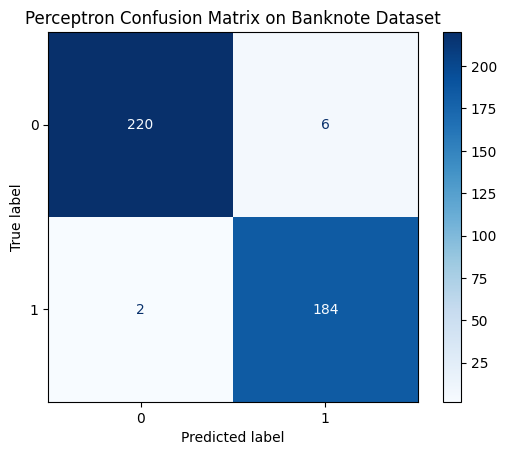

In [30]:
import pandas as pd
from ml import Perceptron, standardize_vectors, train_test_split_arrays
#Only used for displays
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt




url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00267/data_banknote_authentication.txt"
df = pd.read_csv(url, header=None)

# Features (X) and target (y)
X = df.iloc[:, :-1].values   # 4 numeric features
y = df.iloc[:, -1].values    # 0 = authentic, 1 = fake

# --- 2. Standardize features ---
X = standardize_vectors(X)

# --- 3. Train-test split ---
X_train, y_train, X_test, y_test = train_test_split_arrays(
    X, y, train_ratio=0.7, seed=42
)

# --- 4. Initialize perceptron ---
n_features = X_train.shape[1]
model = Perceptron(n_features=n_features)

# --- 5. Train perceptron ---
model.train(X_train, y_train, lr=1.0, epochs=10, verbose=True)

# --- 6. Evaluate ---
y_pred = model.predict(X_test)
print("Predictions:", y_pred)
print("True labels:", y_test)

cm = confusion_matrix(y_test, y_pred)

# Plot using scikit-learn's ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Perceptron Confusion Matrix on Banknote Dataset")
plt.show()



